First 5 Rows:
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant 

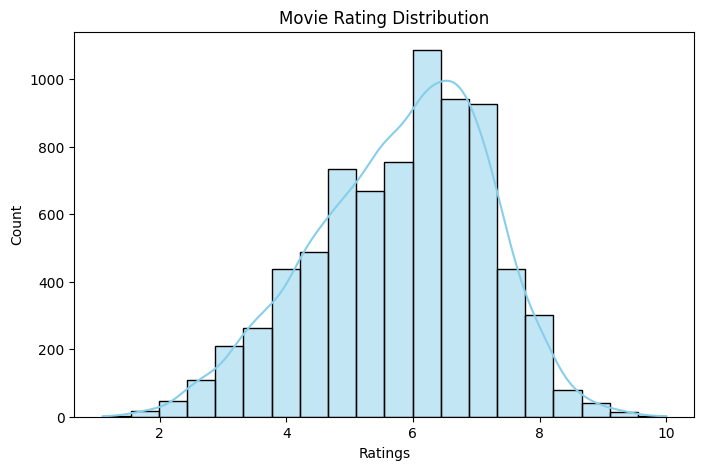

/tmp/ipykernel_4247/2479073018.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')


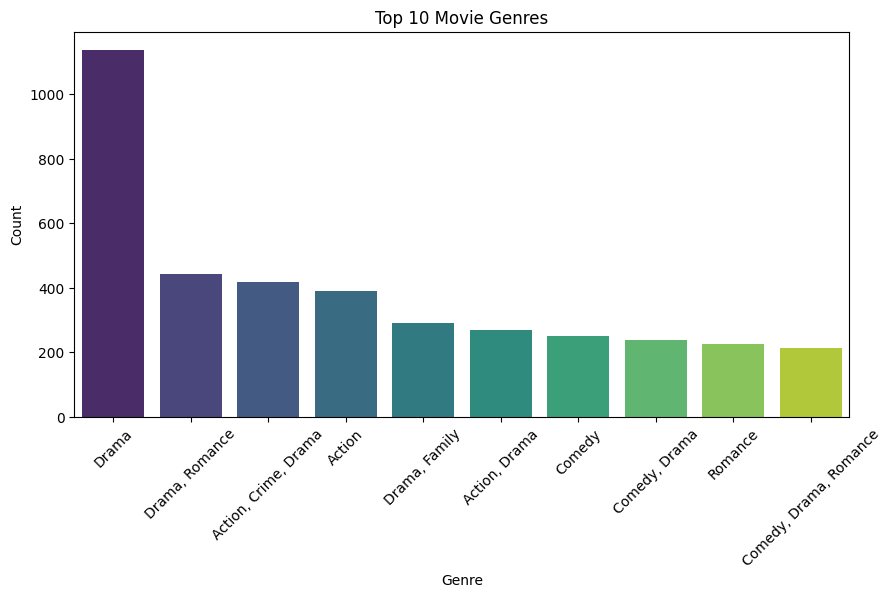


Model Performance
Mean Squared Error: 5.109359300313704
R2 Score: -1.7575864619592454


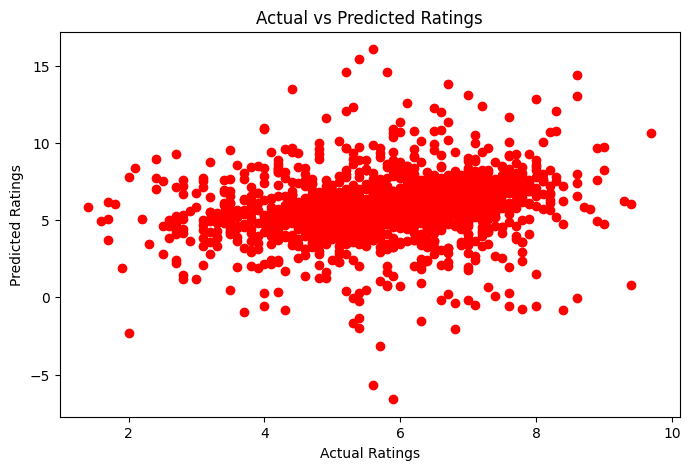


Predicted Movie Rating: 5.945221857156033


In [ ]:
# MOVIE RATING PREDICTION WITH PYTHON + GRAPHS

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load Dataset
data = pd.read_csv("IMDb Movies India.csv", encoding='latin1')

# Display Dataset
print("First 5 Rows:")
print(data.head())

# Select Important Columns
data = data[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Rating']]

# Remove Missing Values
data.dropna(inplace=True)

# -----------------------------
# GRAPH 1 - Rating Distribution
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(data['Rating'], bins=20, kde=True, color='skyblue')
plt.title("Movie Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

# -----------------------------
# GRAPH 2 - Top Genres
# -----------------------------
top_genres = data['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')
plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Combine Features
data['Combined_Features'] = (
    data['Genre'] + ' ' +
    data['Director'] + ' ' +
    data['Actor 1'] + ' ' +
    data['Actor 2'] + ' ' +
    data['Actor 3']
)

# Convert Text to Numerical Data
cv = CountVectorizer(max_features=5000)
X = cv.fit_transform(data['Combined_Features']).toarray()

# Target Variable
y = data['Rating']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict Ratings
predictions = model.predict(X_test)

# -----------------------------
# MODEL EVALUATION
# -----------------------------
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\nModel Performance")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# -----------------------------
# GRAPH 3 - Actual vs Predicted
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions, color='red')
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

# -----------------------------
# PREDICT NEW MOVIE RATING
# -----------------------------
sample_movie = [
    "Action RohitShetty ShahRukhKhan DeepikaPadukone SalmanKhan"
]

sample_data = cv.transform(sample_movie).toarray()

predicted_rating = model.predict(sample_data)

print("\nPredicted Movie Rating:", predicted_rating[0])